In [23]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt # Visualization
import seaborn as sns #Visualization

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt


file_path = '../Dataset/preprocessed_combined_data_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

df.set_index('Date Time', inplace=True)

display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h
Date Time,,,,,,,,,,,,
3/24/2022 0:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0
3/24/2022 0:15,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0
3/24/2022 0:30,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0
3/24/2022 0:45,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0
3/24/2022 1:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3/22/2023 22:45,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0
3/22/2023 23:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0
3/22/2023 23:15,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0


In [24]:
df.describe()

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h
count,34943.000000,34943.000000,34943.000000,34943.000000,34943.000000,34943.000000,34943.000000,34943.000000,34943.000000,34943.000000,34943.000000,34943.000000
mean,198.782263,0.631858,0.335174,29.954149,31.035429,69.883610,0.065801,0.167337,31.014252,69.904101,31.004636,69.918524
std,122.294016,0.482307,0.472058,0.183025,15.449107,19.511768,0.090989,0.163819,15.461529,19.503773,15.465214,19.492783
min,0.000000,0.000000,0.000000,29.120000,-10.000000,30.000000,0.000000,0.000000,-10.000000,30.000000,-10.000000,30.000000
25%,111.152000,0.000000,0.000000,29.830000,19.000000,52.000000,0.000000,0.000000,19.000000,52.000000,19.000000,52.000000
50%,120.152000,1.000000,0.000000,29.940000,28.000000,70.000000,0.000000,0.135417,28.000000,71.000000,28.000000,71.000000
75%,272.924000,1.000000,1.000000,30.060000,40.000000,87.000000,0.135417,0.312500,40.000000,87.000000,40.000000,87.000000
max,611.100000,1.000000,1.000000,30.560000,70.000000,111.000000,0.364583,0.562500,70.000000,111.000000,70.000000,111.000000


Print Pearson Correlation Matrix

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34943 entries, 0 to 34942
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   kW                 34943 non-null  float64
 1   Nantum             34943 non-null  int64  
 2   Season             34943 non-null  int64  
 3   Altimeter reading  34943 non-null  float64
 4   DP Temp (F)        34943 non-null  float64
 5   DB Temp (F)        34943 non-null  int64  
 6   Heat_day           34943 non-null  float64
 7   Cool_day           34943 non-null  float64
 8   DP_12h             34943 non-null  float64
 9   DB_12h             34943 non-null  float64
 10  DP_24h             34943 non-null  float64
 11  DB_24h             34943 non-null  float64
dtypes: float64(9), int64(3)
memory usage: 3.2 MB


None

<Axes: >

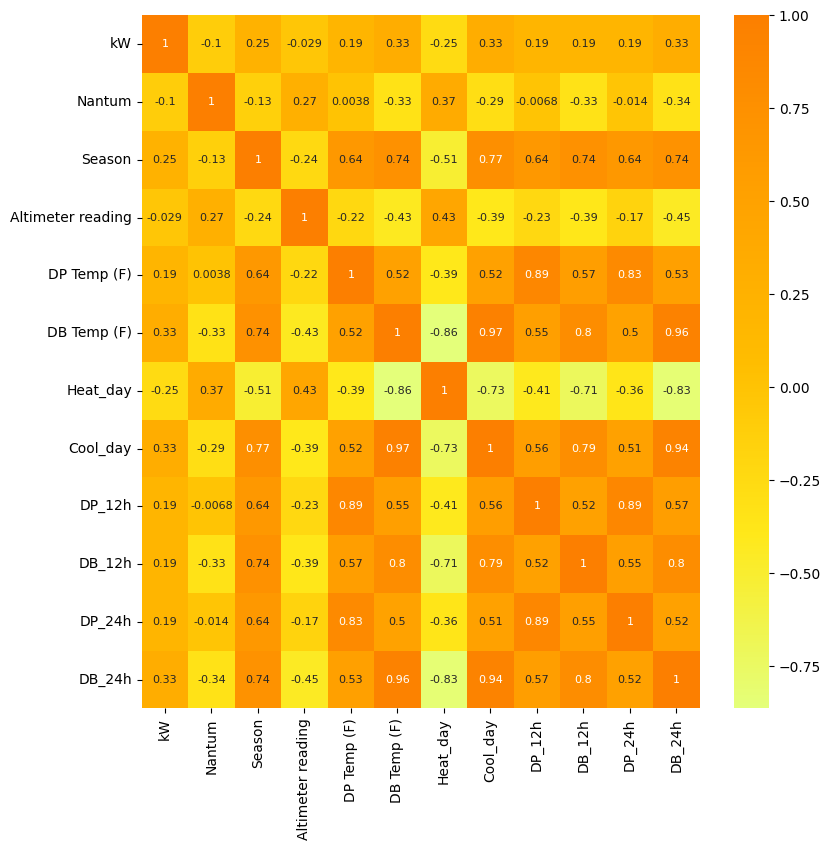

In [25]:
df_2 = df
df_2 = df_2.reset_index(drop=True)
display(df_2.info())

# Use this group of code to change temps from Object type to float type if needed
# df_2['DP Temp (F)'] = pd.to_numeric(df_2['DP Temp (F)'], errors='coerce')
# df_2['DP_12h'] = pd.to_numeric(df_2['DP_12h'], errors='coerce')
# df_2['DP_24h'] = pd.to_numeric(df_2['DP_24h'], errors='coerce')

#display(df_2.info())

#df_2.describe()

corr = df_2.corr()

f,ax = plt.subplots(figsize=(9, 9))
sns.heatmap(corr, cmap = 'Wistia', annot= True, annot_kws={"size": 8}, ax =ax)

# Bigger purple-pink correlation map
#f,ax = plt.subplots(figsize=(18, 18))
#sns.heatmap(corr, annot=True, linewidths=.5, fmt= '.1f',ax=ax)


In [26]:
df_2['Nantum'].unique()

array([0, 1], dtype=int64)

In [27]:
df_2['Season'].unique()


array([0, 1], dtype=int64)

Check if there is any missing value before using random forest algorithm

Text(0.5, 1.0, 'Missing value in the dataset')

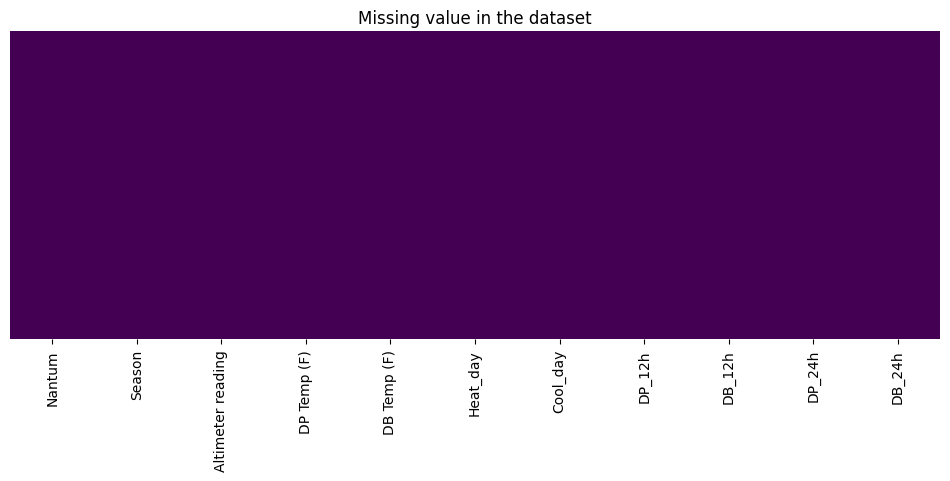

In [28]:
plt.figure(figsize=(12,4))
sns.heatmap(x.isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Missing value in the dataset')


In [57]:
y = df_2.kW

x = df_2.drop('kW',axis = 1 )
x.head()


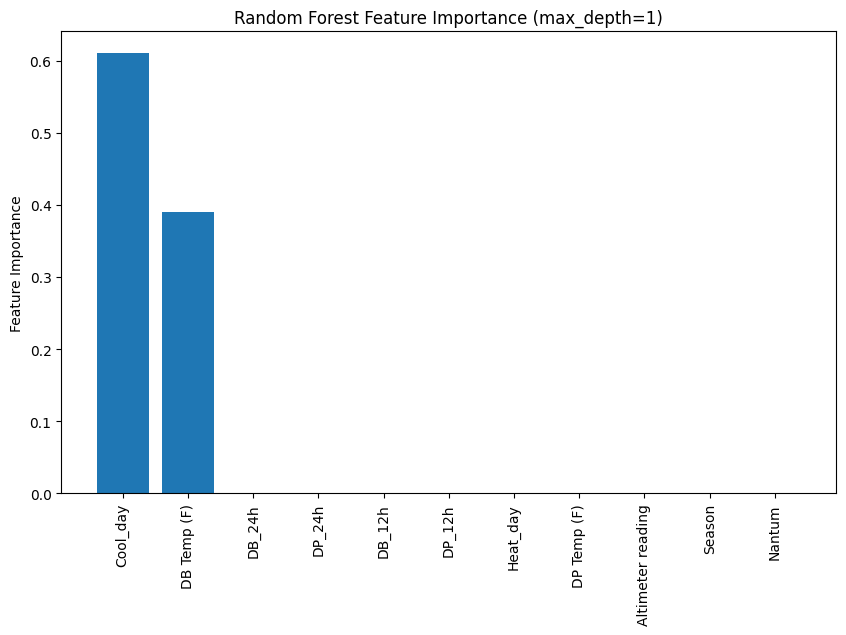

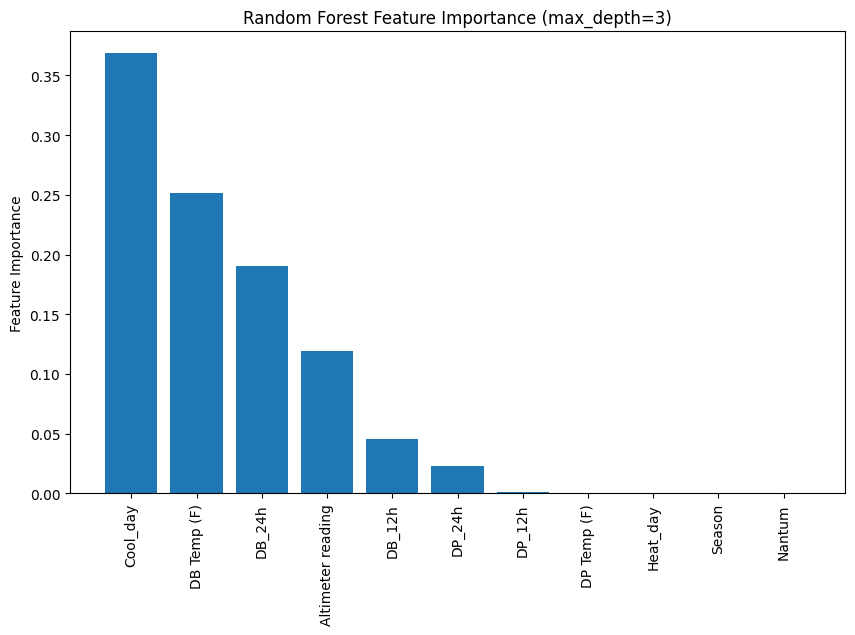

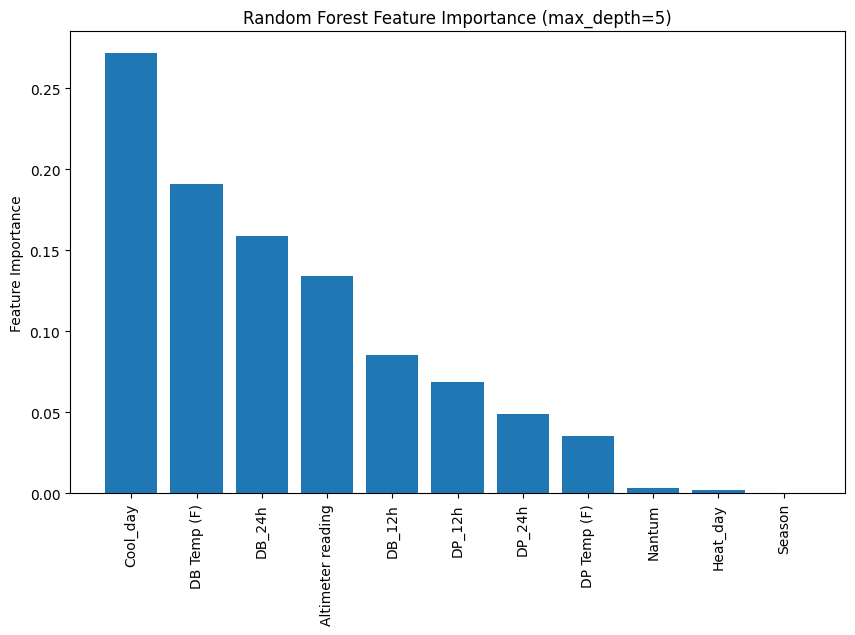

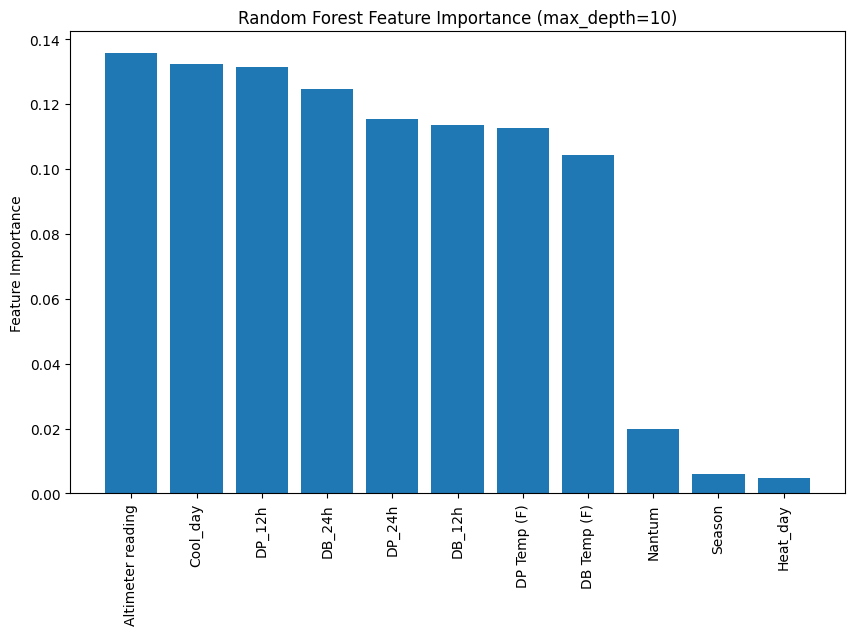

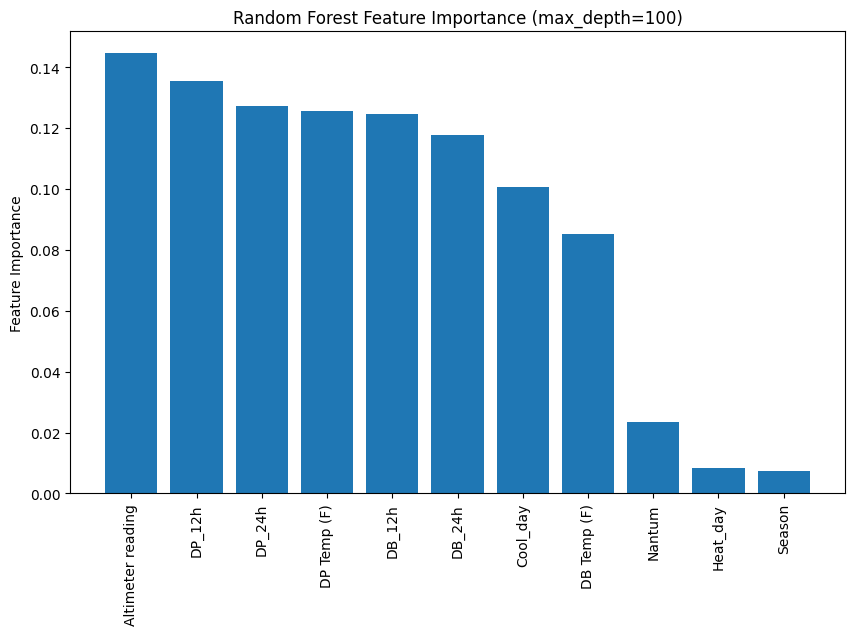

In [58]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

max_depth_values = [1, 3, 5, 10, 100]

for max_depth_value in max_depth_values:

    # n_estimators = number of trees used in the forest
    rf_model = RandomForestRegressor(n_estimators=100,  max_depth= max_depth_value , random_state=42) 
    rf_model.fit(x_train, y_train)

    # impurity based feature importance
    feature_importances = rf_model.feature_importances_

    indices = np.argsort(feature_importances)

    # Plot feature importances

    # Reverse the order to print features on x axis
    indices = indices[::-1]
    plt.figure(figsize=(10, 6))
    plt.bar(range(x_train.shape[1]), feature_importances[indices], align="center")
    plt.xticks(range(x_train.shape[1]), x_train.columns[indices], rotation=90)  # Rotating x-axis labels for better readability
    plt.ylabel("Feature Importance")
    #plt.title("Random Forest Feature Importance Based on Impurity")
    plt.title(f"Random Forest Feature Importance (max_depth={max_depth_value})")
    plt.show()


# Use this group of code to print features on y axis
# plt.figure(figsize=(10, 6))
# plt.barh(range(x_train.shape[1]), feature_importances[indices], align="center")
# plt.yticks(range(x_train.shape[1]), x_train.columns[indices])
# plt.xlabel("Feature Importance")
# plt.title("Random Forest Feature Importance")
# plt.show()
